In [4]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load dataset
data = pd.read_csv('Amazon_Unlocked_Mobile.csv')

# Remove missing values
data = data.dropna(subset=['Reviews', 'Rating']).copy()

# Create sentiment labels
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3
    else ('negative' if rating < 3 else 'neutral')
)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation, numbers and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 3. Tokenization
    words = text.split()

    # 4. Remove stopwords
    words = [word for word in words if word not in stop_words]

    # 5. Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

print("Starting preprocessing...")

data['Cleaned_Reviews'] = data['Reviews'].astype(str).apply(preprocess_text)

print("Preprocessing completed!")

data[['Reviews', 'Cleaned_Reviews', 'Rating', 'Sentiment']].head()

Starting preprocessing...
Preprocessing completed!


,Reviews,Cleaned_Reviews,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone u used hard phone ...,5,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,4,positive
2,Very pleased,pleased,5,positive
3,It works good but it goes slow sometimes but i...,work good go slow sometimes good phone love,4,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,4,positive


In [6]:
# Install scikit-learn
%pip install -q scikit-learn

# Import train_test_split
from sklearn.model_selection import train_test_split

# Features and labels
X = data['Cleaned_Reviews']
y = data['Sentiment']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display sizes
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Note: you may need to restart the kernel to use updated packages.
Training size: (331016,)
Testing size: (82754,)


In [7]:
# Task 3: Feature Extraction Using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit TF-IDF on training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same TF-IDF model
X_test_tfidf = tfidf.transform(X_test)

# Display the shapes
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (331016, 5000)
Testing TF-IDF shape: (82754, 5000)


In [8]:
# Task 4: Train Naive Bayes Classifier

from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
model = MultinomialNB()

# Train the model using the TF-IDF training data
model.fit(X_train_tfidf, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")
print("Predictions completed successfully.")

Naive Bayes model trained successfully.
Predictions completed successfully.


In [9]:
# Task 5: Evaluate the Model

from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print("Accuracy:", accuracy)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8432583319235324

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.76      0.77     19412
     neutral       0.37      0.07      0.12      6352
    positive       0.87      0.96      0.91     56990

    accuracy                           0.84     82754
   macro avg       0.68      0.60      0.60     82754
weighted avg       0.81      0.84      0.82     82754



Confusion Matrix:
[[14710   248  4454]
 [ 2052   462  3838]
 [ 1834   545 54611]]


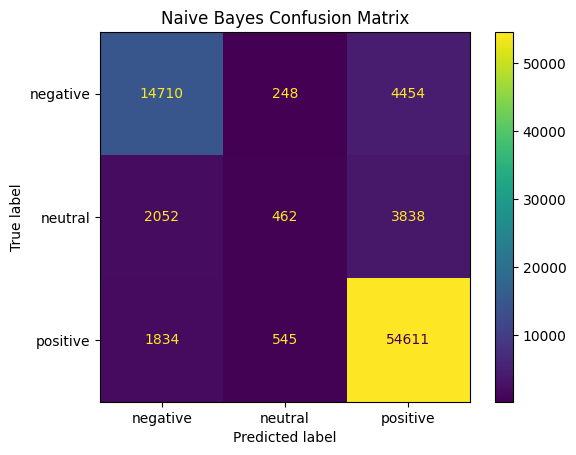

In [10]:
# Task 6: Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define class labels
labels = ['negative', 'neutral', 'positive']

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()